# Building Knowledge Graphs from Raw Text Sources

Final report notebook.

The goal of the project is to transform raw text into a small knowledge graph and then analyze it with methods from the Social Network Analysis course. I use two corpora:

- **course transcripts** as the main dataset;
- **Wikipedia pages about network science** as a cleaner comparison dataset.

The final graph is not supposed to be a perfect knowledge base. It is a practical prototype that shows how raw text can be converted into a graph of concepts and relations.

## What course material is used

This work uses several ideas from the course notebooks and lectures:

- **NetworkX basics**: represent extracted concepts as nodes and relations as edges.
- **Graph design**: define what nodes and edges mean before running metrics.
- **Network projections**: text chunks and entities form a bipartite graph; the entity graph is a projection through shared chunks/sentences.
- **Connected components / giant component**: check whether the extracted graph is coherent or fragmented.
- **Centrality and PageRank**: find central concepts in the extracted knowledge graph.
- **Community detection**: find groups of concepts that appear together.
- **Manual evaluation**: check whether extracted entities and relations are meaningful.

This matches the course idea that a graph project is not only about algorithms, but also about correct graph construction.

In [38]:
%pip install -q pandas matplotlib networkx requests scikit-learn nltk


Note: you may need to restart the kernel to use updated packages.


In [39]:
import json
import re
import time
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import requests
import nltk
from networkx.algorithms.community import greedy_modularity_communities
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

plt.style.use("seaborn-v0_8-whitegrid")

project_dir = Path.cwd().parent if Path.cwd().name == "work" else Path.cwd()
course_dir = project_dir / "course materials"
transcript_files = sorted(course_dir.glob("*_transcript.md"))
transcript_files

[PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/01_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/02_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/03_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/04_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/05_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/06_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/07_transcript.md'),
 PosixPath('/home/nikolay/SyncWork/Documents/mag/SNA Magolego 2026/course materials/08_transcript.md')]

## 1. Data collection

The main dataset is collected from local course transcripts. The second dataset is collected from Wikipedia or loaded from the local Wikipedia cache created during EDA.

I keep the datasets separate during analysis. This is important because transcripts and Wikipedia have different writing styles and different noise levels.

In [40]:
def parse_transcript(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    markers = list(re.finditer(r"(?m)^(\d{1,2}:\d{2})\s+-\s+(.+)$", text))
    if not markers:
        return [{"document_id": path.stem, "corpus": "course_transcripts", "source_file": path.name, "speaker": "unknown", "text": text}]

    rows = []
    for i, marker in enumerate(markers):
        start = marker.end()
        end = markers[i + 1].start() if i + 1 < len(markers) else len(text)
        rows.append({
            "document_id": f"{path.stem}_{i:03d}",
            "corpus": "course_transcripts",
            "source_file": path.name,
            "speaker": marker.group(2).strip(),
            "text": text[start:end].strip(),
        })
    return rows


def fetch_wikipedia_page(title):
    cache_path = project_dir / "work" / "data" / "wikipedia_pages.json"
    cache = json.loads(cache_path.read_text(encoding="utf-8")) if cache_path.exists() else {}
    if title in cache:
        return cache[title]["title"], cache[title]["extract"]

    response = requests.get(
        "https://en.wikipedia.org/w/api.php",
        params={"action": "query", "format": "json", "prop": "extracts", "explaintext": 1, "redirects": 1, "titles": title},
        headers={"User-Agent": "SNA-Magolego-2026-student-project/1.0"},
        timeout=20,
    )
    response.raise_for_status()
    page = next(iter(response.json()["query"]["pages"].values()))
    return page.get("title", title), page.get("extract", "")

wiki_titles = [
    "Social network analysis", "Knowledge graph", "Graph theory", "Network science", "PageRank", "Centrality",
    "Community structure", "Graph drawing", "Graph neural network", "Node2vec", "Link prediction", "NetworkX",
    "Named-entity recognition", "Relation extraction",
]

rows = []
for path in transcript_files:
    rows.extend(parse_transcript(path))

for i, title in enumerate(wiki_titles):
    try:
        real_title, text = fetch_wikipedia_page(title)
    except Exception as error:
        print(f"Could not load Wikipedia page {title!r}: {error}")
        continue
    for j, paragraph in enumerate(p for p in text.split("\n") if len(p.split()) >= 30):
        rows.append({"document_id": f"wiki_{i:02d}_{j:03d}", "corpus": "wikipedia_network_science", "source_file": real_title, "speaker": "Wikipedia", "text": paragraph})

docs = pd.DataFrame(rows)
docs["text"] = docs["text"].fillna("")
docs["words"] = docs["text"].str.findall(r"[A-Za-zА-Яа-я0-9_]+").str.len()
docs = docs[docs["words"] > 5].reset_index(drop=True)

docs.groupby("corpus", as_index=False).agg(source_files=("source_file", "nunique"), documents=("document_id", "count"), words=("words", "sum"))

Could not load Wikipedia page 'Link prediction': 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?action=query&format=json&prop=extracts&explaintext=1&redirects=1&titles=Link+prediction
Could not load Wikipedia page 'NetworkX': 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?action=query&format=json&prop=extracts&explaintext=1&redirects=1&titles=NetworkX
Could not load Wikipedia page 'Named-entity recognition': 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?action=query&format=json&prop=extracts&explaintext=1&redirects=1&titles=Named-entity+recognition
Could not load Wikipedia page 'Relation extraction': 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?action=query&format=json&prop=extracts&explaintext=1&redirects=1&titles=Relation+extraction


,corpus,source_files,documents,words
0,course_transcripts,8,111,130226
1,wikipedia_network_science,10,360,26412


### Data collection conclusion

The course transcripts are the main raw corpus because they directly reflect the course. Wikipedia is used as a cleaner baseline. If the same graph concepts become central in both corpora, this supports that the extracted graph is not random.

## 2. Chunking and preprocessing

Long transcripts are split into smaller chunks. A chunk is a local text context where entities can co-occur and form candidate relations.

In [41]:
def clean_text(text):
    return re.sub(r"\s+", " ", re.sub(r"https?://\S+", " ", text)).strip()

chunks = []
for _, row in docs.iterrows():
    sentences = re.split(r"(?<=[.!?])\s+", clean_text(row["text"]))
    buffer, buffer_words, chunk_no = [], 0, 0
    for sentence in sentences:
        words = re.findall(r"[A-Za-zА-Яа-я0-9_]+", sentence)
        if not words:
            continue
        buffer.append(sentence)
        buffer_words += len(words)
        if buffer_words >= 120:
            chunks.append({"chunk_id": f"{row['document_id']}_chunk_{chunk_no:02d}", "corpus": row["corpus"], "source_file": row["source_file"], "text": " ".join(buffer), "words": buffer_words})
            buffer, buffer_words, chunk_no = [], 0, chunk_no + 1
    if buffer_words >= 30:
        chunks.append({"chunk_id": f"{row['document_id']}_chunk_{chunk_no:02d}", "corpus": row["corpus"], "source_file": row["source_file"], "text": " ".join(buffer), "words": buffer_words})

chunks_df = pd.DataFrame(chunks)
chunks_df.groupby("corpus")["words"].describe()

,count,mean,std,min,25%,50%,75%,max
corpus,,,,,,,,
course_transcripts,1007.0,128.617676,20.679217,30.0,123.0,128.0,137.0,227.0
wikipedia_network_science,373.0,70.292225,30.660785,30.0,45.0,63.0,90.0,152.0


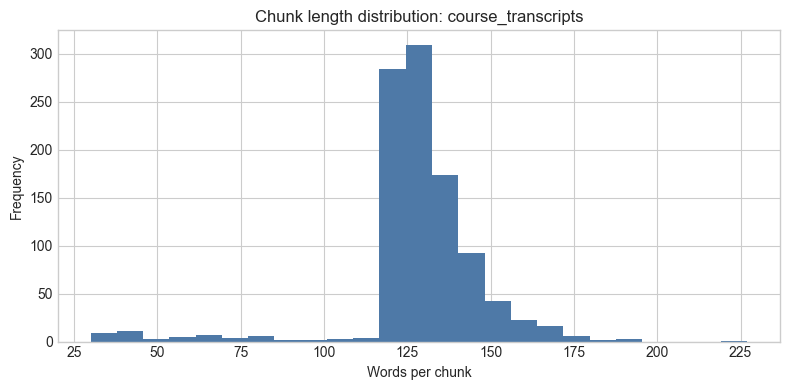

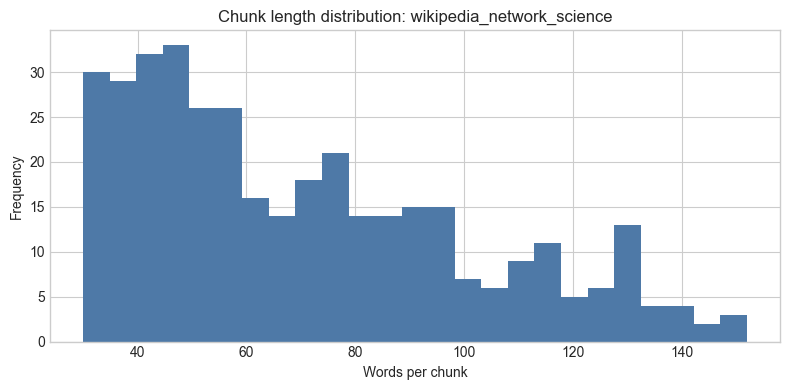

In [42]:
for corpus, part in chunks_df.groupby("corpus"):
    ax = part["words"].plot.hist(bins=25, figsize=(8, 4), color="#4E79A7")
    ax.set_title(f"Chunk length distribution: {corpus}")
    ax.set_xlabel("Words per chunk")
    plt.tight_layout()
    plt.show()

## 3. Entity and keyword extraction

In the final notebook, entity extraction is based on **TF-IDF keywords**, **capitalized multi-word expressions**, and library-based normalization. TF-IDF helps remove words that are too common across documents, while capitalized expressions recover more specific names and topics from the texts.

This is not perfect NER, but it is understandable and works well for a small course project.

In [43]:
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

lemmatizer = WordNetLemmatizer()
custom_noise_words = {
    "okay", "yeah", "yes", "guess", "certain", "obvious", "obviously", "need", "usually", "usual",
    "good", "talk", "say", "maybe", "thing", "things", "kind", "really", "actually", "basically",
    "general", "generally", "large", "small", "time", "idea", "problem", "question", "answer",
    "example", "case", "work", "discuss", "discussion", "result", "list", "possible", "possibility",
    "check", "close", "point", "bit", "better", "course", "lecture", "speaker", "student", "professor",
    "teacher", "guy", "guys", "sorry", "thank", "thanks", "come", "conference", "room", "unidentified",
    "make", "want", "useful", "important", "secondary", "set", "try", "pick", "given", "look", "mean",
}
stopwords = set(ENGLISH_STOP_WORDS) | set(nltk_stopwords.words("english")) | custom_noise_words

special_lemmas = {
    "nodes": "node", "node": "node",
    "edges": "edge", "edge": "edge",
    "graphs": "graph", "graph": "graph",
    "networks": "network", "network": "network",
    "communities": "community", "community": "community",
    "centralities": "centrality", "centrality": "centrality",
    "analyses": "analysis", "analysis": "analysis",
    "degrees": "degree", "degree": "degree",
    "vertices": "vertex", "vertex": "vertex",
    "using": "use", "used": "use", "uses": "use", "use": "use",
    "connected": "connect", "connects": "connect", "connecting": "connect", "connection": "connect",
}


def normalize_word(word):
    word = word.lower()
    if word in stopwords or len(word) < 3:
        return None
    if word in special_lemmas:
        lemma = special_lemmas[word]
    else:
        candidates = [
            lemmatizer.lemmatize(word, pos="n"),
            lemmatizer.lemmatize(word, pos="v"),
            lemmatizer.lemmatize(word, pos="a"),
        ]
        lemma = min(candidates, key=len)
    if lemma in stopwords or len(lemma) < 3:
        return None
    return lemma


def analyze_text(text):
    words = re.findall(r"[A-Za-z][A-Za-z\-]{2,}", str(text).lower())
    return [item for item in (normalize_word(word) for word in words) if item]


def normalize_phrase(phrase):
    words = re.findall(r"[A-Za-z][A-Za-z\-]{2,}", str(phrase))
    normalized = [normalize_word(word) for word in words]
    normalized = [word for word in normalized if word]
    collapsed = []
    for word in normalized:
        if not collapsed or collapsed[-1] != word:
            collapsed.append(word)
    if len(set(collapsed)) < 2:
        return None
    return " ".join(collapsed)


def top_tfidf_terms(part, top_n=70, relative_floor=0.18):
    vectorizer = TfidfVectorizer(
        tokenizer=analyze_text,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.28,
    )
    matrix = vectorizer.fit_transform(part["text"])
    ranked = sorted(zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).A1), key=lambda x: x[1], reverse=True)
    if not ranked:
        return []
    score_floor = ranked[0][1] * relative_floor
    terms = []
    for term, score in ranked:
        if score < score_floor:
            continue
        normalized = normalize_phrase(term) if " " in term else normalize_word(term)
        if normalized and normalized not in terms:
            terms.append(normalized)
        if len(terms) >= top_n:
            break
    return terms


def capitalized_multiword_terms(part, min_count=2, top_n=60):
    counts = Counter()
    pattern = re.compile(r"\b(?:[A-Z][a-z]+|[A-Z]{2,})(?:\s+(?:[A-Z][a-z]+|[A-Z]{2,})){1,}\b")
    for text in part["text"]:
        for phrase in pattern.findall(text):
            normalized = normalize_phrase(phrase)
            if normalized:
                counts[normalized] += 1
    return [term for term, count in counts.most_common(top_n) if count >= min_count]


def terms_in_text(text, terms):
    text_terms = set(analyze_text(text))
    found = set()
    for term in terms:
        parts = term.split()
        if len(parts) == 1 and parts[0] in text_terms:
            found.add(term)
        elif len(parts) > 1 and all(part in text_terms for part in parts):
            found.add(term)
    return found


terms_by_corpus, entity_tables, capitalized_terms_tables = {}, [], []
for corpus, part in chunks_df.groupby("corpus"):
    tfidf_terms = top_tfidf_terms(part)
    capitalized_terms = capitalized_multiword_terms(part)
    terms = list(dict.fromkeys(tfidf_terms + capitalized_terms))
    terms_by_corpus[corpus] = terms

    capitalized_terms_tables.append(pd.DataFrame({"corpus": corpus, "capitalized_multiword_term": capitalized_terms}))

    counts = Counter()
    for _, row in part.iterrows():
        counts.update(terms_in_text(row["text"], terms))

    table = pd.DataFrame(counts.most_common(), columns=["entity", "chunk_mentions"])
    table.insert(0, "corpus", corpus)
    entity_tables.append(table)

    print(corpus)
    print("Capitalized multi-word candidates:")
    display(pd.DataFrame({"term": capitalized_terms[:20]}))
    print("Final extracted terms:")
    display(table.head(25))

capitalized_terms_df = pd.concat(capitalized_terms_tables, ignore_index=True)
entities_df = pd.concat(entity_tables, ignore_index=True)

course_transcripts
Capitalized multi-word candidates:


,term
0,ilia karpov
1,moscow state university
2,giant connect component
3,social network analysis
4,graph neural network
5,arthur andersen
6,arthur anderson
7,new york
8,michael bernstein
9,political block network


Final extracted terms:


,corpus,entity,chunk_mentions
0,course_transcripts,network,250
1,course_transcripts,different,211
2,course_transcripts,likely,200
3,course_transcripts,structure,180
4,course_transcripts,information,177
5,course_transcripts,way,155
6,course_transcripts,edge,155
7,course_transcripts,compute,149
8,course_transcripts,simple,149
9,course_transcripts,connect,140


wikipedia_network_science
Capitalized multi-word candidates:


,term
0,betweenness centrality
1,larry page
2,jon kleinberg
3,alpha user
4,knowledge graph
5,new york
6,stanford university
7,google toolbar
8,google directory
9,transportation centrality


Final extracted terms:


,corpus,entity,chunk_mentions
0,wikipedia_network_science,node,100
1,wikipedia_network_science,edge,79
2,wikipedia_network_science,link,70
3,wikipedia_network_science,number,67
4,wikipedia_network_science,vertex,64
5,wikipedia_network_science,centrality,60
6,wikipedia_network_science,pagerank,58
7,wikipedia_network_science,social,56
8,wikipedia_network_science,social network,53
9,wikipedia_network_science,measure,53


### How entity extraction works

The extraction is intentionally simple:

1. Use `TfidfVectorizer` to rank important terms inside each corpus.
2. Remove terms that are too rare with `min_df`.
3. Remove terms that are too common across documents with `max_df`.
4. Add frequent capitalized multi-word expressions such as names, tools and topic names.
5. Normalize tokens with NLTK stemming.
6. Keep only terms above a relative TF-IDF score floor or frequent enough as capitalized expressions.

This is weaker than a full NER model, but it is transparent and easy to explain during the presentation.

## 4. Relation extraction

The EDA notebook used mostly co-occurrence: if two entities appeared in the same chunk, they were connected.

Here relation extraction is slightly improved:

- entities are extracted at sentence level;
- if two entities appear in the same sentence, an edge is created;
- if a relation cue is found between or near them, the edge receives a meaningful label;
- otherwise the edge is marked as `CO_OCCURS_WITH`.

So the graph contains both simple co-occurrence relations and weak semantic relations.

In [44]:
relation_patterns = [
    (r"\b(use|uses|used|using|apply|applies|applied)\b", "USES"),
    (r"\b(connect|connects|connected|link|links|linked)\b", "CONNECTS_TO"),
    (r"\b(classify|classifies|classification|predict|predicts|prediction)\b", "PREDICTS_OR_CLASSIFIES"),
    (r"\b(cluster|clusters|clustering|community|communities)\b", "CLUSTERS"),
    (r"\b(measure|measures|centrality|pagerank|rank|ranks)\b", "MEASURES_IMPORTANCE"),
    (r"\b(detect|detects|detection|find|finds|search)\b", "DETECTS"),
    (r"\b(generate|generates|model|models|simulate|simulates)\b", "MODELS"),
    (r"\b(extract|extracts|extraction)\b", "EXTRACTS"),
]


def relation_label(sentence):
    low = sentence.lower()
    for pattern, label in relation_patterns:
        if re.search(pattern, low):
            return label
    return "CO_OCCURS_WITH"


rows = []
for _, row in chunks_df.iterrows():
    for sentence in re.split(r"(?<=[.!?])\s+", row["text"]):
        terms = sorted(terms_in_text(sentence, terms_by_corpus.get(row["corpus"], [])))
        if len(terms) < 2 or len(terms) > 6:
            continue
        for source, target in combinations(terms, 2):
            rows.append({
                "corpus": row["corpus"],
                "chunk_id": row["chunk_id"],
                "source": source,
                "target": target,
                "relation": relation_label(sentence),
                "sentence": sentence[:350],
            })

relations_df = pd.DataFrame(rows)
relations_df.groupby(["corpus", "relation"], as_index=False).size().sort_values(["corpus", "size"], ascending=[True, False])

,corpus,relation,size
2,course_transcripts,CO_OCCURS_WITH,3431
0,course_transcripts,CLUSTERS,658
8,course_transcripts,USES,622
1,course_transcripts,CONNECTS_TO,455
6,course_transcripts,MODELS,441
3,course_transcripts,DETECTS,244
7,course_transcripts,PREDICTS_OR_CLASSIFIES,150
5,course_transcripts,MEASURES_IMPORTANCE,73
4,course_transcripts,EXTRACTS,6
11,wikipedia_network_science,CO_OCCURS_WITH,1314


### How relation extraction works

The relation extractor does not understand language perfectly. It uses a practical rule:

- same sentence → candidate relation;
- relation verb/cue nearby → semantic label;
- no clear cue → `CO_OCCURS_WITH`.

This is acceptable for this project because the task asks for a practical prototype, not a perfect universal knowledge graph.

## 5. Graph construction

For each corpus I build a separate entity graph.

Nodes are extracted concepts/entities. Edges are extracted relations. If the same relation appears multiple times, its weight increases.

In [45]:
graphs = {}
for corpus, part in relations_df.groupby("corpus"):
    G = nx.Graph(corpus=corpus)
    grouped = part.groupby(["source", "target"], as_index=False).agg(weight=("chunk_id", "count"), relation=("relation", lambda x: Counter(x).most_common(1)[0][0]), example_sentence=("sentence", "first"))
    for _, row in grouped.iterrows():
        G.add_edge(row["source"], row["target"], weight=int(row["weight"]), relation=row["relation"], example_sentence=row["example_sentence"])
    graphs[corpus] = G

stats = []
for corpus, G in graphs.items():
    components = list(nx.connected_components(G))
    stats.append({
        "corpus": corpus,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "components": len(components),
        "largest_component_nodes": len(max(components, key=len)) if components else 0,
        "density": nx.density(G),
        "avg_degree": sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() else 0,
    })
graph_stats = pd.DataFrame(stats)
graph_stats

,corpus,nodes,edges,components,largest_component_nodes,density,avg_degree
0,course_transcripts,82,1917,1,82,0.577236,46.756098
1,wikipedia_network_science,86,1340,1,86,0.366621,31.162791


## 6. Centrality and PageRank

Here I use the same idea as in the course centrality notebook: important nodes can be found not only by counting direct connections, but also by considering the importance of their neighbors.

I calculate:

- weighted degree;
- degree centrality;
- betweenness centrality;
- PageRank.

In [46]:
centrality_tables = []
for corpus, G in graphs.items():
    degree_weighted = dict(G.degree(weight="weight"))
    degree_centrality = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G, weight="weight", k=min(100, G.number_of_nodes()), seed=42) if G.number_of_nodes() > 2 else {}
    pagerank = nx.pagerank(G, weight="weight") if G.number_of_nodes() else {}
    table = pd.DataFrame({
        "corpus": corpus,
        "entity": list(G.nodes()),
        "weighted_degree": [degree_weighted.get(node, 0) for node in G.nodes()],
        "degree_centrality": [degree_centrality.get(node, 0) for node in G.nodes()],
        "betweenness": [betweenness.get(node, 0) for node in G.nodes()],
        "pagerank": [pagerank.get(node, 0) for node in G.nodes()],
    }).sort_values("pagerank", ascending=False)
    centrality_tables.append(table)
    print(corpus)
    display(table.head(20))
centrality_df = pd.concat(centrality_tables, ignore_index=True)

course_transcripts


,corpus,entity,weighted_degree,degree_centrality,betweenness,pagerank
35,course_transcripts,network,517,0.876543,0.000243,0.040197
13,course_transcripts,edge,399,0.777778,0.001707,0.028895
22,course_transcripts,information,366,0.802469,0.002409,0.027210
49,course_transcripts,structure,351,0.864198,0.007616,0.026125
29,course_transcripts,likely,328,0.851852,0.002174,0.024552
12,course_transcripts,different,320,0.851852,0.002926,0.024312
10,course_transcripts,data,299,0.790123,0.009876,0.023098
7,course_transcripts,community,306,0.765432,0.009026,0.022883
8,course_transcripts,compute,285,0.790123,0.006429,0.021698
9,course_transcripts,connect,280,0.753086,0.006883,0.021461


wikipedia_network_science


,corpus,entity,weighted_degree,degree_centrality,betweenness,pagerank
27,wikipedia_network_science,node,406,0.788235,0.007341,0.047264
13,wikipedia_network_science,edge,249,0.635294,0.006040,0.029005
23,wikipedia_network_science,link,231,0.682353,0.017500,0.028488
5,wikipedia_network_science,centrality,236,0.576471,0.005707,0.028271
30,wikipedia_network_science,pagerank,200,0.552941,0.019825,0.028249
59,wikipedia_network_science,vertex,210,0.541176,0.004763,0.024788
41,wikipedia_network_science,social,193,0.552941,0.036814,0.024641
28,wikipedia_network_science,number,189,0.658824,0.022503,0.023374
63,wikipedia_network_science,analysis,182,0.494118,0.012947,0.022196
44,wikipedia_network_science,structure,177,0.658824,0.015281,0.021940


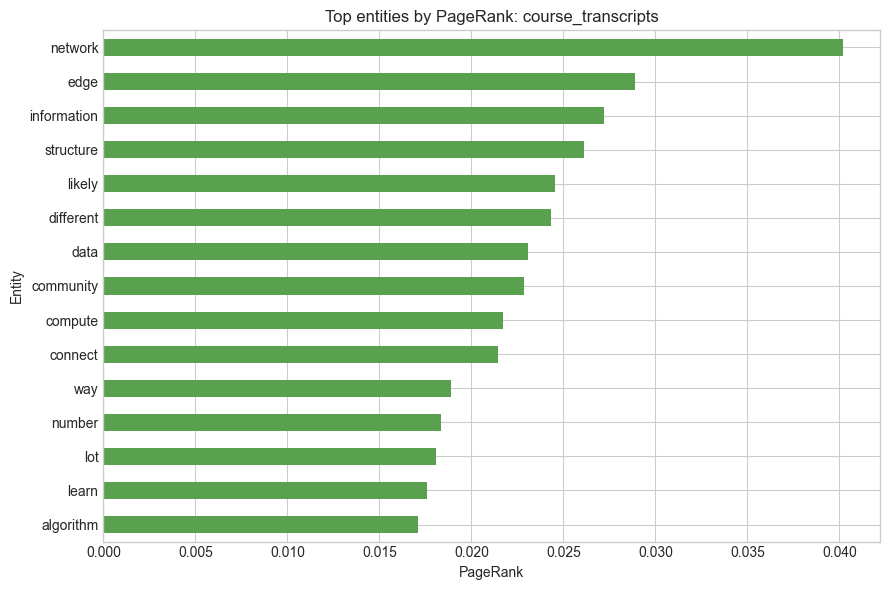

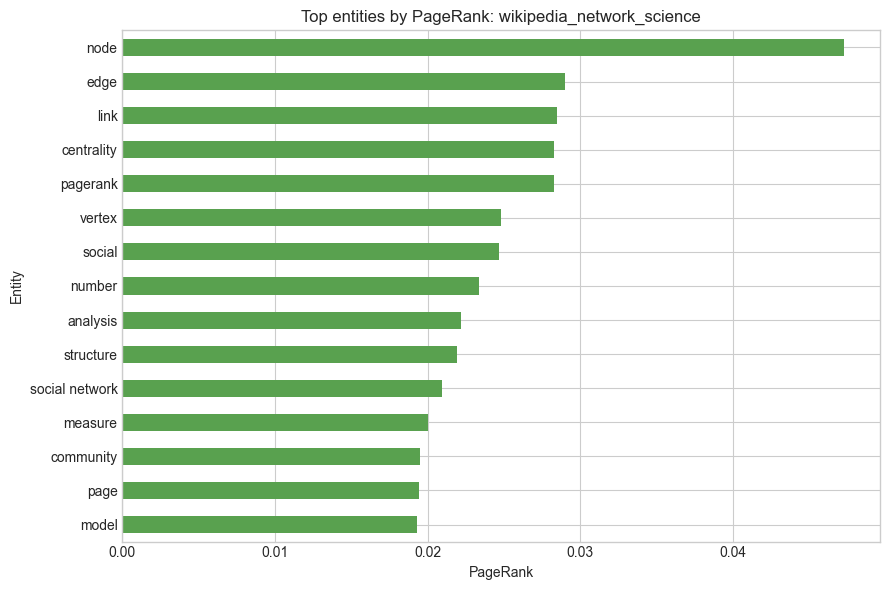

In [47]:
for corpus, part in centrality_df.groupby("corpus"):
    top = part.head(15).sort_values("pagerank")
    ax = top.plot.barh(x="entity", y="pagerank", legend=False, figsize=(9, 6), color="#59A14F")
    ax.set_title(f"Top entities by PageRank: {corpus}")
    ax.set_xlabel("PageRank")
    ax.set_ylabel("Entity")
    plt.tight_layout()
    plt.show()

### Centrality conclusion

Centrality gives an interpretable summary of the corpus. In the transcript graph, central nodes usually correspond to methods and tools discussed in the course. In the Wikipedia graph, central nodes are cleaner conceptual terms. This is exactly why both datasets are useful: one gives the course perspective, and the other gives a cleaner external baseline.

## 7. Community detection

The course materials include community detection examples: greedy modularity, Louvain-like logic, Leiden/Bayan discussions, and clustering.

Here I use NetworkX greedy modularity communities because it is simple, reproducible, and does not require extra external solvers.

In [48]:
community_rows, node_community = [], {}
for corpus, G in graphs.items():
    communities = sorted(greedy_modularity_communities(G, weight="weight"), key=len, reverse=True) if G.number_of_edges() else []
    for community_id, community in enumerate(communities):
        sub = centrality_df[(centrality_df["corpus"] == corpus) & (centrality_df["entity"].isin(community))]
        top_entities = sub.sort_values("pagerank", ascending=False).head(8)["entity"].tolist()
        community_rows.append({"corpus": corpus, "community_id": community_id, "size": len(community), "top_entities": ", ".join(top_entities)})
        for node in community:
            node_community[(corpus, node)] = community_id
communities_df = pd.DataFrame(community_rows)
communities_df.head(20)

,corpus,community_id,size,top_entities
0,course_transcripts,0,22,"network, data, way, lot, process, happen, clas..."
1,course_transcripts,1,19,"different, compute, algorithm, strategy, think..."
2,course_transcripts,2,16,"edge, structure, likely, community, connect, n..."
3,course_transcripts,3,13,"information, learn, neighbor, build, feature, ..."
4,course_transcripts,4,6,"simple, start, second, random, let, path"
5,course_transcripts,5,6,"user, hard, negative, object, item, ilia karpov"
6,wikipedia_network_science,0,22,"node, edge, centrality, vertex, number, measur..."
7,wikipedia_network_science,1,21,"link, pagerank, page, google, value, search, r..."
8,wikipedia_network_science,2,18,"social, analysis, social network, network anal..."
9,wikipedia_network_science,3,10,"model, study, theory, random, graph theory, kn..."


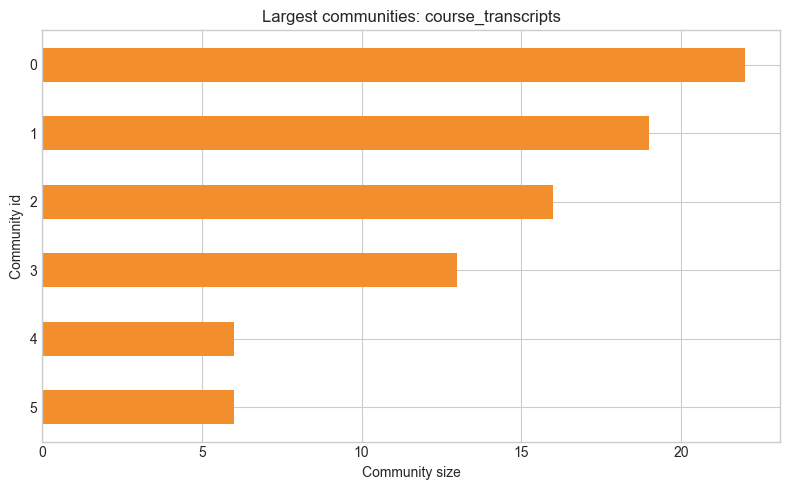

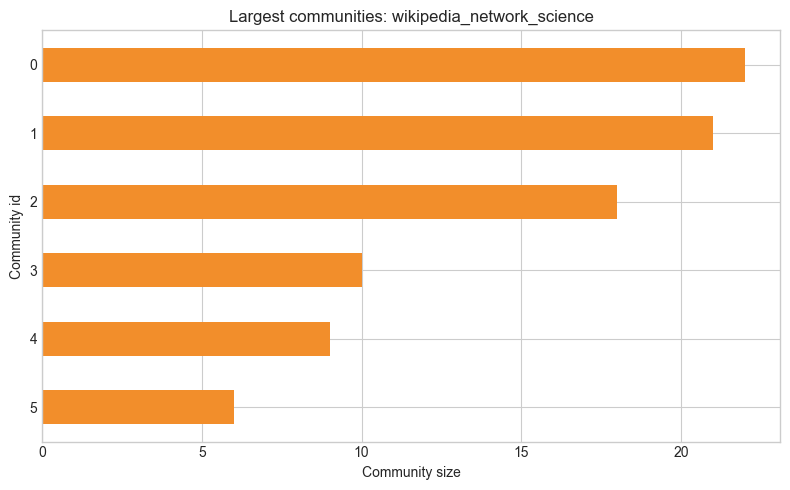

,corpus,community_id,size,top_entities
0,course_transcripts,0,22,"network, data, way, lot, process, happen, clas..."
1,course_transcripts,1,19,"different, compute, algorithm, strategy, think..."
2,course_transcripts,2,16,"edge, structure, likely, community, connect, n..."
3,course_transcripts,3,13,"information, learn, neighbor, build, feature, ..."
4,course_transcripts,4,6,"simple, start, second, random, let, path"
5,course_transcripts,5,6,"user, hard, negative, object, item, ilia karpov"
6,wikipedia_network_science,0,22,"node, edge, centrality, vertex, number, measur..."
7,wikipedia_network_science,1,21,"link, pagerank, page, google, value, search, r..."
8,wikipedia_network_science,2,18,"social, analysis, social network, network anal..."
9,wikipedia_network_science,3,10,"model, study, theory, random, graph theory, kn..."


In [49]:
for corpus, part in communities_df.groupby("corpus"):
    top = part.head(12).sort_values("size")
    ax = top.plot.barh(x="community_id", y="size", legend=False, figsize=(8, 5), color="#F28E2B")
    ax.set_title(f"Largest communities: {corpus}")
    ax.set_xlabel("Community size")
    ax.set_ylabel("Community id")
    plt.tight_layout()
    plt.show()
display(communities_df.head(12))

### Community detection conclusion

Communities show that the graph is not just one unordered bag of terms. Concepts form groups: for example, centrality/PageRank-related terms, community/clustering terms, embedding/link-prediction terms, and dataset/tool examples. This is useful for presenting the graph as a map of course topics.

## 8. Graph visualization

For readability I visualize only the most central nodes. Node color corresponds to detected community, and node size corresponds to PageRank.

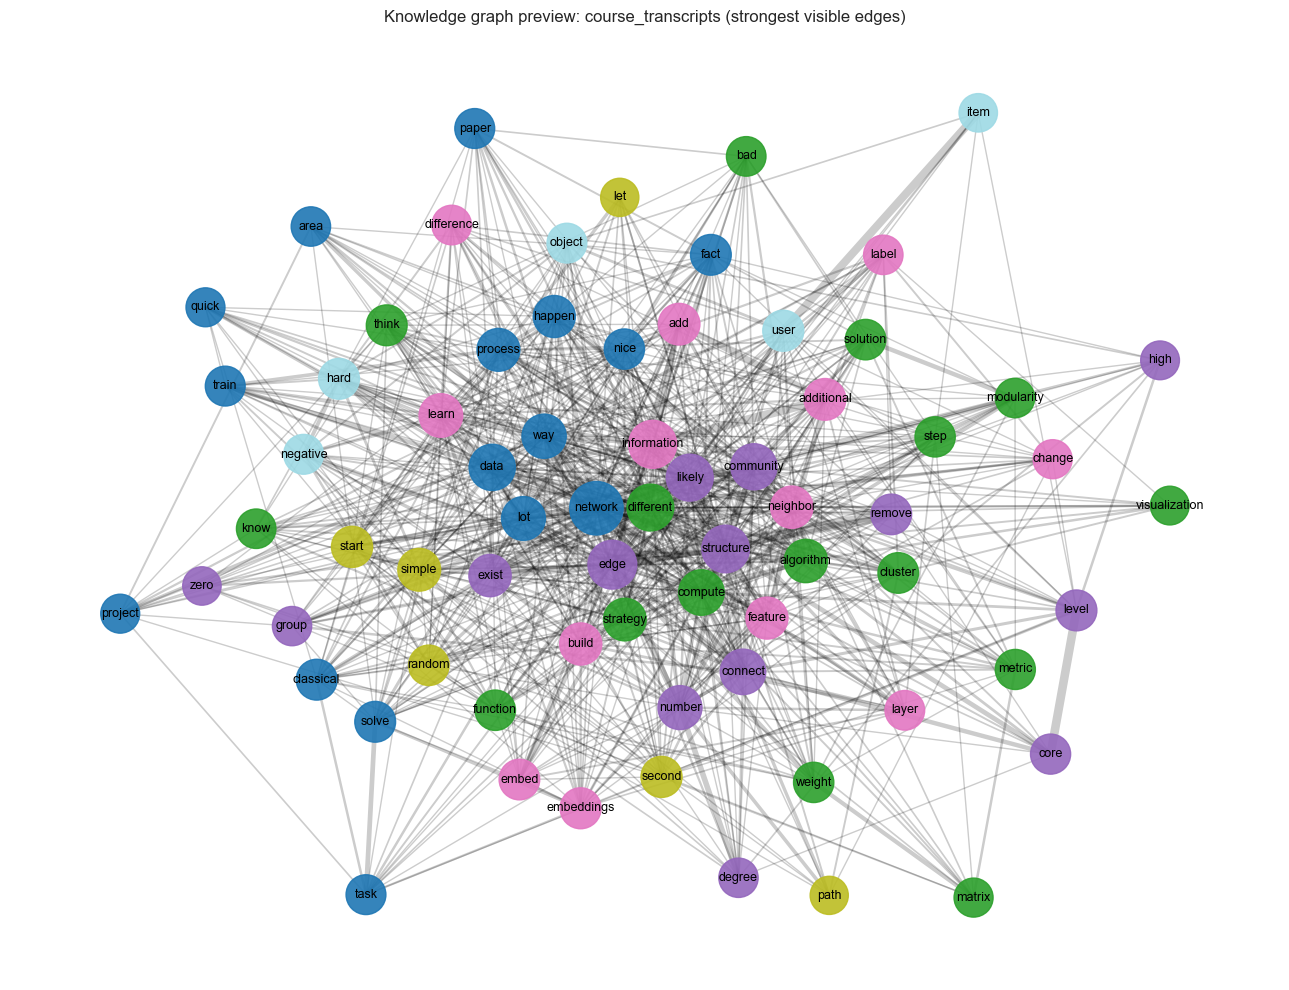

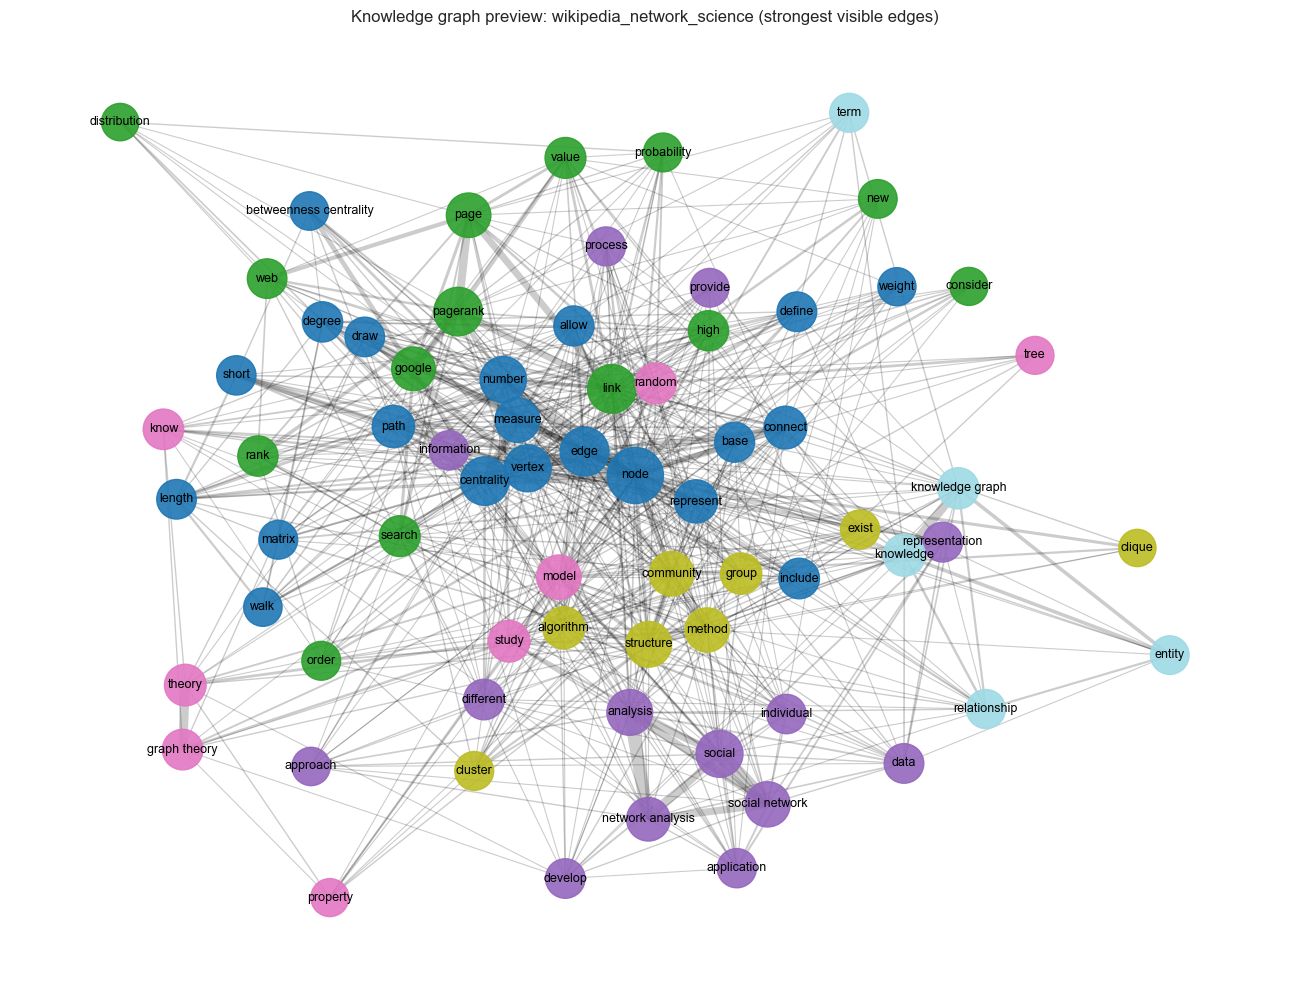

In [54]:
for corpus, G in graphs.items():
    top_nodes = centrality_df[centrality_df["corpus"] == corpus].head(70)["entity"].tolist()
    H = G.subgraph(top_nodes).copy()
    if H.number_of_edges() == 0:
        continue

    weights = [data.get("weight", 1) for _, _, data in H.edges(data=True)]
    min_weight = sorted(weights)[int(len(weights) * 0.65)] if len(weights) > 5 else 1
    weak_edges = [(u, v) for u, v, data in H.edges(data=True) if data.get("weight", 1) < min_weight]
    H.remove_edges_from(weak_edges)
    H.remove_nodes_from(list(nx.isolates(H)))

    pos = nx.spring_layout(H, seed=42, k=1.1, weight="weight")
    pr = centrality_df[centrality_df["corpus"] == corpus].set_index("entity")["pagerank"].to_dict()
    sizes = [600 + 22000 * pr.get(node, 0) for node in H.nodes()]
    colors = [node_community.get((corpus, node), -1) for node in H.nodes()]
    widths = [0.4 + 0.2 * H[u][v].get("weight", 1) for u, v in H.edges()]

    plt.figure(figsize=(13, 10))
    nx.draw_networkx_edges(H, pos, alpha=0.2, width=widths)
    nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=colors, cmap="tab20", alpha=0.9)
    nx.draw_networkx_labels(H, pos, font_size=9)
    plt.title(f"Knowledge graph preview: {corpus} (strongest visible edges)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 9. Manual evaluation sample

The project requires checking extraction quality. Below I create samples of entities and relations that can be manually marked as correct or incorrect.

For the presentation, it is enough to manually inspect a small sample and report approximate precision.

In [51]:
entity_eval = pd.concat([
    part.head(100).sample(min(20, len(part)), random_state=42)
    for _, part in entities_df.groupby("corpus")
], ignore_index=True)
entity_eval["manual_is_correct"] = ""
entity_eval

,corpus,entity,chunk_mentions,manual_is_correct
0,course_transcripts,michael bernstein,2,
1,course_transcripts,network,250,
2,course_transcripts,negative,39,
3,course_transcripts,fact,100,
4,course_transcripts,lot,135,
5,course_transcripts,arthur anderson,1,
6,course_transcripts,happen,137,
7,course_transcripts,community,112,
8,course_transcripts,information,177,
9,course_transcripts,core,41,


In [52]:
relation_eval = pd.concat([
    part.sample(min(25, len(part)), random_state=42)
    for _, part in relations_df.groupby("corpus")
], ignore_index=True)
relation_eval["manual_is_correct"] = ""
relation_eval[["corpus", "source", "target", "relation", "manual_is_correct", "sentence"]].head(30)

,corpus,source,target,relation,manual_is_correct,sentence
0,course_transcripts,function,network,CO_OCCURS_WITH,,So it is the cubed function of the vertex size...
1,course_transcripts,connect,solve,CONNECTS_TO,,"If you have the nice feature vector, you can d..."
2,course_transcripts,data,nice,CO_OCCURS_WITH,,"And this nice guy, he's not so young now, beca..."
3,course_transcripts,happen,learn,CO_OCCURS_WITH,,"For example, for the Cassin similarity, it may..."
4,course_transcripts,data,step,CO_OCCURS_WITH,,And the second point is if you have done data ...
5,course_transcripts,embeddings,step,USES,,But the good idea to model those nodes that we...
6,course_transcripts,bad,train,MODELS,,Which means that you need either to inject the...
7,course_transcripts,core,level,CO_OCCURS_WITH,,"So here is the simple graph, and we can just t..."
8,course_transcripts,process,second,CO_OCCURS_WITH,,The second problem here is that usually dealin...
9,course_transcripts,let,start,CO_OCCURS_WITH,,So let's start with it.


## 10. Final summary

The project now has a complete prototype pipeline:

1. collect raw text from course transcripts and Wikipedia;
2. split texts into chunks;
3. extract entities and TF-IDF concepts;
4. extract simple relations from sentence co-occurrence and relation cues;
5. construct separate knowledge graphs for each corpus;
6. analyze graph structure with components, centrality, PageRank and communities;
7. visualize the resulting graphs;
8. prepare manual evaluation samples.

The main limitation is extraction quality: rule-based entity and relation extraction is noisy. However, this is acceptable for the project goal because the task is to build a practical graph prototype and analyze it, not to create a perfect industrial knowledge graph.

For the slides, the most important story is: **raw text can be transformed into a graph, and course SNA methods help explain which concepts are central and how they group into communities.**

In [53]:
summary = {
    "documents": docs.groupby("corpus")["document_id"].count().to_dict(),
    "chunks": chunks_df.groupby("corpus")["chunk_id"].count().to_dict(),
    "entities": entities_df.groupby("corpus")["entity"].count().to_dict(),
    "relations": relations_df.groupby("corpus")["relation"].count().to_dict(),
    "graph_stats": graph_stats.to_dict(orient="records"),
    "community_count": communities_df.groupby("corpus")["community_id"].count().to_dict(),
}
summary

{'documents': {'course_transcripts': 111, 'wikipedia_network_science': 360},
 'chunks': {'course_transcripts': 1007, 'wikipedia_network_science': 373},
 'entities': {'course_transcripts': 85, 'wikipedia_network_science': 90},
 'relations': {'course_transcripts': 6080, 'wikipedia_network_science': 3651},
 'graph_stats': [{'corpus': 'course_transcripts',
   'nodes': 82,
   'edges': 1917,
   'components': 1,
   'largest_component_nodes': 82,
   'density': 0.5772357723577236,
   'avg_degree': 46.75609756097561},
  {'corpus': 'wikipedia_network_science',
   'nodes': 86,
   'edges': 1340,
   'components': 1,
   'largest_component_nodes': 86,
   'density': 0.36662106703146374,
   'avg_degree': 31.162790697674417}],
 'community_count': {'course_transcripts': 6, 'wikipedia_network_science': 6}}